In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import torch.nn.functional as F

from tokenizers.models import BPE
from tokenizers import Tokenizer
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace
from tokenizers.processors import TemplateProcessing

In [2]:
from pathlib import Path

In [3]:
path = Path("/kaggle/input/datasets/phnguyencs/chinese-vi/dataset")

In [4]:
train_path = path / "train"
public_path =path / "public_test"
private_path = path / "private_test"

In [5]:
zh, vi = [], []
with open(train_path / "train.zh", "r", encoding="utf-8") as f:
    zh = f.read().splitlines()

with open(train_path / "train.vi", "r", encoding="utf-8") as f:
    vi = f.read().splitlines()

print(len(zh), len(vi))
for i in range(5):
    print(zh[i], vi[i])

32061 32061
我 会 给 您 拿 一些 。 Tôi sẽ mang cho bạn một_ít . 
如果 你 还 有 什么 需要 的 就 告诉 我 。 Nếu bạn cần điều gì khác hãy cho tôi biết . 
不用 担心 那件 事 。 Đừng lo_lắng về điều đó . 
我 要 买 它 你 不 需要 把 它 包 起来 。 Tôi sẽ mang nó và bạn không cần phải gói nó lại . 
你 改变 吗 ？ Bạn thay_đổi không ? 


In [6]:
import pandas as pd

df= pd.DataFrame({
    "zh": zh,
    "vi": vi
}
)

## Tokenizer

In [7]:
zh_tokenizer = Tokenizer(BPE(unk_token="[UNK]"))

vi_tokenizer = Tokenizer(BPE(unk_token="[UNK]"))
zh_trainer = BpeTrainer(
    vocab_size=8000,
    special_tokens = ["[SOS]", "[EOS]", "[PAD]", "[UNK]"],
    min_frequency = 5
)

vi_trainer = BpeTrainer(
    vocab_size=8000,
    special_tokens = ["[SOS]", "[EOS]", "[PAD]", "[UNK]"],
    min_frequency = 5
)

def _yield(data):
    for sample in data:
        yield(sample)


zh_tokenizer.train_from_iterator(_yield(df['zh'].tolist()), zh_trainer)    
vi_tokenizer.train_from_iterator(_yield(df['vi'].tolist()), vi_trainer)    

In [8]:
zh_vocab = zh_tokenizer.get_vocab()
vi_vocab = vi_tokenizer.get_vocab()

print(len(zh_vocab), len(vi_vocab))

8000 8000


In [9]:
print(list(zh_vocab.keys())[:10])

[' 一 点 的 吗 ？', '即', '新 ', '请 问 ', '海 ', '東', '是 的 。', '带到 ', '仰', '这 次 ']


In [10]:
print(list(vi_vocab.keys())[:10])

['hải_', ' ta', 'hộ_chiếu', 'nên ', '[UNK]', 'ịch', 'anh ta', 'ong ', 'Đây có phải ', 'Xin mời ']


In [11]:

ZH_PAD_TOKEN_ID = zh_tokenizer.token_to_id("[PAD]")
ZH_SOS_TOKEN_ID = zh_tokenizer.token_to_id("[SOS]")
ZH_EOS_TOKEN_ID = zh_tokenizer.token_to_id("[EOS]")

VI_PAD_TOKEN_ID = vi_tokenizer.token_to_id("[PAD]")
VI_SOS_TOKEN_ID = vi_tokenizer.token_to_id("[SOS]")
VI_EOS_TOKEN_ID = vi_tokenizer.token_to_id("[EOS]")

print(
    (ZH_PAD_TOKEN_ID, ZH_SOS_TOKEN_ID, ZH_EOS_TOKEN_ID),
    (VI_PAD_TOKEN_ID, VI_SOS_TOKEN_ID, VI_EOS_TOKEN_ID),
)

(2, 0, 1) (2, 0, 1)


Text(0.5, 1.0, 'vi')

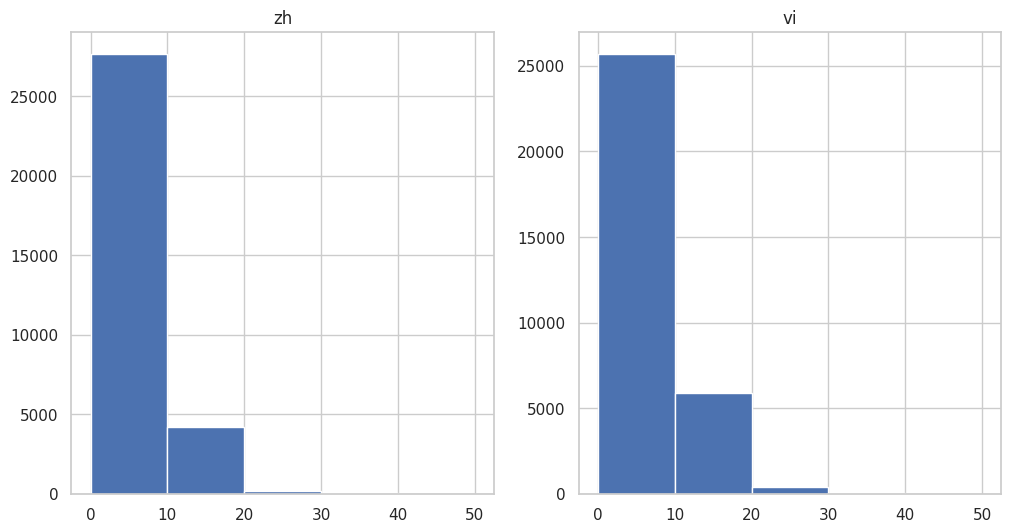

In [12]:
import matplotlib.pyplot as plt 
import seaborn as sns




sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

zh_count = df['zh'].apply(lambda x: len(zh_tokenizer.encode(x).ids)).tolist()
vi_count = df['vi'].apply(lambda x: len(vi_tokenizer.encode(x).ids)).tolist()
ax[0].hist(zh_count, range=(0,50), bins=5)
ax[0].set_title("zh")
ax[1].hist(vi_count, range=(0,50), bins=5)
ax[1].set_title("vi")

In [13]:
zh_tokenizer.post_processor = TemplateProcessing(
    single = "[SOS] $A [EOS]",
    special_tokens=[
       ("[SOS]" , ZH_SOS_TOKEN_ID),
       ("[EOS]" , ZH_EOS_TOKEN_ID),
    ]
)
vi_tokenizer.post_processor = TemplateProcessing(
    single = "[SOS] $A [EOS]",
    special_tokens=[
       ("[SOS]" , VI_SOS_TOKEN_ID),
       ("[EOS]" , VI_EOS_TOKEN_ID),
    ]
)

## Loading Data 

In [14]:
class CustomDataset(Dataset):
    def __init__(self, zh, vi, zh_tokenizer, vi_tokenizer, isTest=True):
        self.zh = zh
        self.vi = vi if not isTest else None 
        self.zh_tokenizer = zh_tokenizer
        self.vi_tokenizer = vi_tokenizer
        self.isTest = isTest
    def __len__(self) :
       return len(self.zh) 
    def __getitem__(self,idx):
        zh=  self.zh[idx] 
        zh_ids = self.zh_tokenizer.encode(zh).ids
        zh_ids = torch.tensor(zh_ids).squeeze(0)
        
        if self.isTest:
            return {
                "src": zh_ids,
                "tgt_input": None,
                "tgt_output": None
            }
        vi =  self.vi[idx] 
        vi_ids = self.vi_tokenizer.encode(vi).ids
        vi_ids = torch.tensor(vi_ids).squeeze(0)
        tgt_input = vi_ids[:-1]        
        tgt_output = vi_ids[1:]        
        return {
            "src": zh_ids,
            "tgt_input": tgt_input,
            "tgt_output": tgt_output
        }

In [15]:
df_train = df.sample(int(0.95 * len(df)), random_state=42)
df_val = df.drop(index=df_train.index)
len(df_train), len(df_val)

(30457, 1604)

In [16]:
train_data = CustomDataset(df_train['zh'].tolist(), df_train['vi'].tolist(), 
                           zh_tokenizer, vi_tokenizer, False)
val_data = CustomDataset(df_val['zh'].tolist(), df_val['vi'].tolist(), 
                           zh_tokenizer, vi_tokenizer, False)

In [17]:
train_data[10]

{'src': tensor([   0, 2792, 3009, 2630,    4,  308, 6670,  497, 3828, 2867, 3469,    1]),
 'tgt_input': tensor([   0,  222,  612, 5748, 2418,  472, 6121]),
 'tgt_output': tensor([ 222,  612, 5748, 2418,  472, 6121,    1])}

In [18]:
MAX_LEN = 25
def collate_fn(batch):
    src = [b["src"][:MAX_LEN ] for b in batch]
    tgt_input = [b["tgt_input"][:MAX_LEN ] for b in batch]
    tgt_output= [b["tgt_output"][:MAX_LEN ] for b in batch]

    src = nn.utils.rnn.pad_sequence(
        sequences=src, batch_first=True, padding_value=ZH_PAD_TOKEN_ID
    )
    tgt_input = nn.utils.rnn.pad_sequence(
        sequences=tgt_input, batch_first=True, padding_value=VI_PAD_TOKEN_ID
    )
    tgt_output = nn.utils.rnn.pad_sequence(
        sequences=tgt_output, batch_first=True, padding_value=VI_PAD_TOKEN_ID
    )

    src_key_padding_mask = src == ZH_PAD_TOKEN_ID
    tgt_key_padding_mask = tgt_input == VI_PAD_TOKEN_ID
    return {
       "src" : src,
       "tgt_input": tgt_input,
       "tgt_output": tgt_output,
       "src_key_padding_mask": src_key_padding_mask,
       "tgt_key_padding_mask": tgt_key_padding_mask,
    }

In [19]:
BATCH_SIZE = 128
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, collate_fn=collate_fn, shuffle=True)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, collate_fn=collate_fn, shuffle=False)

In [20]:
len(train_loader), len(val_loader)

(238, 13)

## Model

In [21]:
def create_mask(size, device):
    mask = torch.full((size, size), fill_value=float("-inf"), device=device)
    mask = torch.triu(mask, diagonal=1)
    return mask


In [22]:
create_mask(4, 'cpu')

tensor([[0., -inf, -inf, -inf],
        [0., 0., -inf, -inf],
        [0., 0., 0., -inf],
        [0., 0., 0., 0.]])

In [23]:
class RMSNorm(nn.Module):
    def __init__(self, dim, eps = 1e-6):
        super().__init__()
        self.dim=  dim
        self.eps = eps
        self.scale = nn.Parameter(torch.ones(dim))
    def forward(self, x):
        rms = x.pow(2).mean(dim = -1, keepdim=True)
        x = x * torch.rsqrt(rms + self.eps)
        return x * self.scale

In [24]:
def rotate_half(x):
    x1, x2 = x.chunk(2, dim =-1)
    return torch.cat((x2, -x1), dim=  -1)

In [25]:
def rope_cache(dim, seq_len, device):
    half_dim = dim // 2
    angle = 1 / (10000 ** (torch.arange(0, half_dim, device=  device)/half_dim))
    positions = torch.arange(0, seq_len, device=device)
    angle = torch.outer(positions, angle)[None, None, :,  :]
    sin = torch.repeat_interleave(angle.sin(), 2, dim=-1)
    cos = torch.repeat_interleave(angle.cos(), 2, dim=-1)
    return sin, cos

In [26]:
def apply_rope(x, sin , cos):
    return x * cos + rotate_half(x) * sin

In [27]:
class Attension(nn.Module):
    def __init__(self, d_model, nhead, dropout, use_rope=True):
        super().__init__()
        self.d_model = d_model
        self.nhead = nhead
        self.head_dim = self.d_model // self.nhead
        self.dropout = nn.Dropout(dropout)
        self.scale = self.head_dim ** -0.5
        self.use_rope = use_rope
        self.q = nn.Linear(d_model, d_model)
        self.k = nn.Linear(d_model, d_model)
        self.v = nn.Linear(d_model, d_model)
        self.o = nn.Linear(d_model, d_model)

    def forward(self, q, k, v, attn_mask, key_padding_mask):
        batch_size, q_len, _ = q.size()
        k_len = k.size(1)
        q = self.q(q).view(batch_size, q_len, self.nhead, self.head_dim).transpose(1, 2)
        k = self.k(k).view(batch_size, k_len, self.nhead, self.head_dim).transpose(1, 2)
        v = self.v(v).view(batch_size, k_len, self.nhead, self.head_dim).transpose(1, 2)

        if self.use_rope:
            sin, cos = rope_cache(self.head_dim, max(q_len, k_len), q.device)
            q = apply_rope(q, sin[:, :, :q_len, :], cos[:, :, :q_len, :])
            k = apply_rope(k, sin[:, :, :k_len, :], cos[:, :, :k_len, :])

        weight = torch.matmul(q, k.transpose(-2, -1)) * self.scale
        if attn_mask is not None:
            weight = weight + attn_mask[None, None, :, :]
        if key_padding_mask is not None:
            weight = torch.masked_fill(weight, key_padding_mask[:, None, None, :], float('-inf'))
        weight = torch.softmax(weight, dim=-1)
        weight = self.dropout(weight)
        out = torch.matmul(weight, v)
        out = out.transpose(1, 2).contiguous().view(batch_size, q_len, self.d_model)
        out = self.o(out)
        return out

In [28]:
class FeedForward(nn.Module):
    def __init__(self, dim, ffn, dropout):
        super().__init__()
        self.w1 = nn.Linear(dim, ffn)
        self.w2 = nn.Linear(dim, ffn)
        self.w3 = nn.Linear(ffn, dim)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x):
        x = nn.functional.silu(
            self.w1(x)) * self.w2(x)
        
        return self.w3(self.dropout(x))

In [29]:
class Encoder(nn.Module):
    def __init__(self, dim, nhead, ffn, dropout ):
        super().__init__()
        self.norm1 = RMSNorm(dim)
        self.norm2 = RMSNorm(dim)
        self.dropout = nn.Dropout(dropout)
        self.attn = Attension(dim, nhead, dropout)
        self.feed = FeedForward(dim, ffn, dropout)

        
    def forward(self, x, src_key_padding_mask):
        x = x + self.dropout(self.attn(
           self.norm1(x),
           self.norm1(x),
           self.norm1(x),
            None, src_key_padding_mask
        ))
        x = x + self.dropout(self.feed(self.norm2(x)))
        return x

In [30]:
class Decoder(nn.Module):
    def __init__(self, dim, nhead, ffn, dropout):
        super().__init__()
        self.norm1 = RMSNorm(dim)
        self.norm2 = RMSNorm(dim)
        self.norm3 = RMSNorm(dim)
        self.attn1 = Attension(dim, nhead, dropout)
        self.attn2 = Attension(dim, nhead, dropout, use_rope=False)
        self.dropout = nn.Dropout(dropout)
        self.feed = FeedForward(dim, ffn, dropout)

    def forward(self, memory, memory_key_padding_mask, tgt, tgt_mask, tgt_key_padding_mask):
        tgt = tgt + self.dropout(self.attn1(
           self.norm1(tgt),
           self.norm1(tgt),
           self.norm1(tgt),
            tgt_mask, tgt_key_padding_mask
        ))
        tgt = tgt + self.dropout(self.attn2(
           self.norm2(tgt),
           memory,
           memory,
            None, memory_key_padding_mask
        ))
        tgt = tgt  + self.dropout(self.feed(self.norm3(tgt)))
        return tgt

In [31]:
import math

In [32]:
class NMT(nn.Module):
    def __init__(self, dim, nhead, zh_size, vi_size, dropout, ffn, num_encoders, num_decoders):
        super().__init__()
        self.scale = math.sqrt(dim)
        self.zh_embedd = nn.Embedding(zh_size, dim)
        self.vi_embedd = nn.Embedding(vi_size, dim)
        self.token_dropout = 0.15
        self.encoder = nn.ModuleList(
            [
                Encoder(dim, nhead, ffn, dropout) for _ in range(num_encoders)
            ]
        )
        self.decoder = nn.ModuleList(
            [
                Decoder(dim, nhead, ffn, dropout) for _ in range(num_decoders)
            ]
        )
        self.dropout = nn.Dropout(dropout)
        self.norm = RMSNorm(dim)
        self.head = nn.Linear(dim, vi_size, bias=False)
        self.head.weight = self.vi_embedd.weight

    def _apply_token_dropout(self, tokens, pad_id, unk_id, special_token_ids):
        if not self.training or self.token_dropout <= 0:
            return tokens
        keep_mask = tokens == pad_id
        for special_token_id in special_token_ids:
            keep_mask = keep_mask | (tokens == special_token_id)
        drop_mask = (torch.rand_like(tokens.float()) < self.token_dropout) & (~keep_mask)
        return torch.where(drop_mask, torch.full_like(tokens, unk_id), tokens)

    def forward(self, src, src_key_padding_mask,
                tgt, tgt_mask, tgt_key_padding_mask):
        src = self._apply_token_dropout(src, ZH_PAD_TOKEN_ID, zh_tokenizer.token_to_id("[UNK]"), [ZH_SOS_TOKEN_ID, ZH_EOS_TOKEN_ID])
        tgt = self._apply_token_dropout(tgt, VI_PAD_TOKEN_ID, vi_tokenizer.token_to_id("[UNK]"), [VI_SOS_TOKEN_ID, VI_EOS_TOKEN_ID])
        src = self.dropout(self.zh_embedd(src) * self.scale)
        memory = src
        for layer in self.encoder:
            memory = layer(memory, src_key_padding_mask)

        tgt = self.dropout(self.vi_embedd(tgt) * self.scale)
        for layer in self.decoder:
            tgt = layer(memory, src_key_padding_mask, tgt, tgt_mask, tgt_key_padding_mask)
        out = self.head(self.norm(tgt))
        return out.permute(0, 2, 1)

In [33]:
DIM = 768
NHEAD = 6
ZH_SIZE = 8000
VI_SIZE = 8000
NUM_ENCODERS = 8
NUM_DECODERS = 8
FFN = 3072
DROPOUT = 0.3

In [34]:
model = NMT(DIM, NHEAD, ZH_SIZE, VI_SIZE,DROPOUT, FFN, NUM_ENCODERS, NUM_DECODERS )

In [35]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
model = model.to(DEVICE)

In [36]:
total_params = 0
for p in model.parameters():
    total_params += p.numel()
print(total_params)

182373120


In [37]:
criterion = nn.CrossEntropyLoss(ignore_index=VI_PAD_TOKEN_ID, label_smoothing=0.15)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=5e-4,
    betas=(0.9, 0.98),
    weight_decay=3e-2 ,
)

## Training

In [38]:
from tqdm import tqdm
from torch.nn.utils import clip_grad_norm_

In [39]:

def train(epoch, epochs, train_loader, scheduler):
    model.train()
    correct, count, losses = 0, 0, []

    for inputs in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]"):
        src = inputs["src"].to(DEVICE)
        tgt_input = inputs["tgt_input"].to(DEVICE)
        tgt_output = inputs["tgt_output"].to(DEVICE)
        src_key_padding_mask = inputs["src_key_padding_mask"].to(DEVICE)
        tgt_key_padding_mask = inputs["tgt_key_padding_mask"].to(DEVICE)
        tgt_mask = create_mask(tgt_input.size(1), DEVICE)

        optimizer.zero_grad(set_to_none=True)
        output = model(
            src,
            src_key_padding_mask,
            tgt_input,
            tgt_mask,
            tgt_key_padding_mask
        )
        loss = criterion(output, tgt_output)
        losses.append(loss.item())
        pred = output.argmax(1)
        non_pad_mask = tgt_output != VI_PAD_TOKEN_ID
        correct += (pred[non_pad_mask] == tgt_output[non_pad_mask]).sum().item()
        loss.backward()
        clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        count += non_pad_mask.sum().item()

    epoch_loss = sum(losses) / len(losses)
    epoch_acc = correct / count
    return epoch_acc, epoch_loss


In [40]:
def evaluate(epoch, epochs, val_loader):
    model.eval()
    correct, count, losses = 0, 0, []
    with torch.no_grad():
        for inputs in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]"):
            src = inputs["src"].to(DEVICE)
            tgt_input = inputs["tgt_input"].to(DEVICE)
            tgt_output = inputs["tgt_output"].to(DEVICE)
            src_key_padding_mask = inputs["src_key_padding_mask"].to(DEVICE)
            tgt_key_padding_mask = inputs["tgt_key_padding_mask"].to(DEVICE)
            tgt_mask = create_mask(tgt_input.size(1), DEVICE)

            output = model(
                src,
                src_key_padding_mask,
                tgt_input,
                tgt_mask,
                tgt_key_padding_mask
            )
            loss = criterion(output, tgt_output)
            losses.append(loss.item())
            pred = output.argmax(1)
            non_pad_mask = tgt_output != VI_PAD_TOKEN_ID
            correct += (pred[non_pad_mask] == tgt_output[non_pad_mask]).sum().item()
            count += non_pad_mask.sum().item()

    epoch_loss = sum(losses) / len(losses)
    epoch_acc = correct / count
    return epoch_acc, epoch_loss


In [41]:
!pip install sacrebleu

In [42]:
import sacrebleu

@torch.no_grad()
def beam_search_decode(src, src_key_padding_mask, beam_size=4, max_len=None, length_penalty=0.6):
    model.eval()
    device = src.device
    if max_len is None:
        max_len = src.size(1) + 5

    beams = [([VI_SOS_TOKEN_ID], 0.0, False)]

    for _ in range(max_len - 1):
        candidates = []
        all_finished = True

        for tokens, score, finished in beams:
            if finished:
                candidates.append((tokens, score, True))
                continue

            all_finished = False
            ys = torch.tensor([tokens], dtype=torch.long, device=device)
            tgt_mask = create_mask(ys.size(1), device)
            tgt_key_padding_mask = ys == VI_PAD_TOKEN_ID
            output = model(src, src_key_padding_mask, ys, tgt_mask, tgt_key_padding_mask)
            log_probs = torch.log_softmax(output[:, :, -1], dim=1).squeeze(0)
            topk_scores, topk_ids = torch.topk(log_probs, beam_size)

            for token_score, token_id in zip(topk_scores.tolist(), topk_ids.tolist()):
                next_tokens = tokens + [token_id]
                candidates.append((next_tokens, score + token_score, token_id == VI_EOS_TOKEN_ID))

        beams = sorted(
            candidates,
            key=lambda item: item[1] / (((5 + len(item[0])) / 6) ** length_penalty),
            reverse=True,
        )[:beam_size]

        if all_finished:
            break

    return vi_tokenizer.decode(beams[0][0], skip_special_tokens=True)

@torch.no_grad()
def compute_bleu(zhs, vis):
    preds = []
    for zh in zhs:
        src = zh_tokenizer.encode(zh).ids
        src = torch.tensor(src, device=DEVICE).unsqueeze(0)
        src = src[:, :MAX_LEN]
        src_key_padding_mask = src == ZH_PAD_TOKEN_ID
        preds.append(beam_search_decode(src, src_key_padding_mask, beam_size=4, max_len=src.size(1) + 5))
    bleu = sacrebleu.corpus_bleu(preds, [vis], force=True)
    return bleu.score

In [43]:

train_losses, val_losses, train_accs, val_accs, bleu_scores = [], [], [], [], []

In [44]:
min_loss = float("inf")

In [45]:
def training(epochs, train_loader, test_loader, bleu_every=2):
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=5e-4,
        total_steps=epochs * len(train_loader),
        pct_start=0.1,
        anneal_strategy="cos",
        div_factor=10.0,
        final_div_factor=100.0,
    )
    model_path = "./model.pth"
    zh_tokenizer_path = "./zh_tokenizer.json"
    zh_tokenizer.save(zh_tokenizer_path)

    vi_tokenizer_path = "./vi_tokenizer.json"
    vi_tokenizer.save(vi_tokenizer_path)
    best_bleu = -1.0
    patience = 3
    stale_epochs = 0
    for epoch in range(epochs):
        train_acc, train_loss = train(epoch, epochs, train_loader, scheduler)
        val_acc, val_loss = evaluate(epoch, epochs, test_loader)
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        global min_loss
        bleu_score = None
        if epoch % bleu_every == 0 or epoch == epochs - 1:
            bleu_score = compute_bleu(
                df_val["zh"].iloc[:100].tolist(),
                df_val["vi"].iloc[:100].tolist(),
            )
            bleu_scores.append(bleu_score)
            if bleu_score > best_bleu:
                best_bleu = bleu_score
                stale_epochs = 0
                torch.save(model.state_dict(), model_path)
            else:
                stale_epochs += 1
        elif val_loss < min_loss:
            min_loss = val_loss
            torch.save(model.state_dict(), model_path)

        print(f"  Train Loss: {train_loss:.4f}, Train Acc: {train_acc*100:.2f}%")
        print(f"  Val Loss: {val_loss:.4f}, Val Acc: {val_acc*100:.2f}%")
        if bleu_score is None:
            print("  Val BLEU: skipped\n")
        else:
            print(f"  Val BLEU: {bleu_score:.2f}\n")

        if stale_epochs >= patience:
            print(f"  Early stopping after {patience} BLEU checks without improvement.\n")
            break


In [46]:

training(
    epochs=40, train_loader=train_loader, test_loader=val_loader
)

Epoch 1/40 [Val]: 100%|██████████| 13/13 [00:05<00:00,  2.54it/s]


  Train Loss: 95.9642, Train Acc: 1.66%
  Val Loss: 29.9306, Val Acc: 12.52%
  Val BLEU: 0.00



Epoch 2/40 [Val]: 100%|██████████| 13/13 [00:05<00:00,  2.55it/s]


  Train Loss: 26.3374, Train Acc: 4.59%
  Val Loss: 14.9566, Val Acc: 12.92%
  Val BLEU: skipped



Epoch 3/40 [Val]: 100%|██████████| 13/13 [00:05<00:00,  2.54it/s]


...

  Train Loss: 7.5484, Train Acc: 13.14%
  Val Loss: 7.4621, Val Acc: 13.83%
  Val BLEU: 0.31



Epoch 20/40 [Val]: 100%|██████████| 13/13 [00:05<00:00,  2.52it/s]


  Train Loss: 7.5231, Train Acc: 13.19%
  Val Loss: 7.4460, Val Acc: 13.89%
  Val BLEU: skipped



Epoch 21/40 [Val]: 100%|██████████| 13/13 [00:05<00:00,  2.51it/s]


  Train Loss: 7.5022, Train Acc: 13.25%
  Val Loss: 7.4356, Val Acc: 13.85%
  Val BLEU: 0.45

  Early stopping after 3 BLEU checks without improvement.



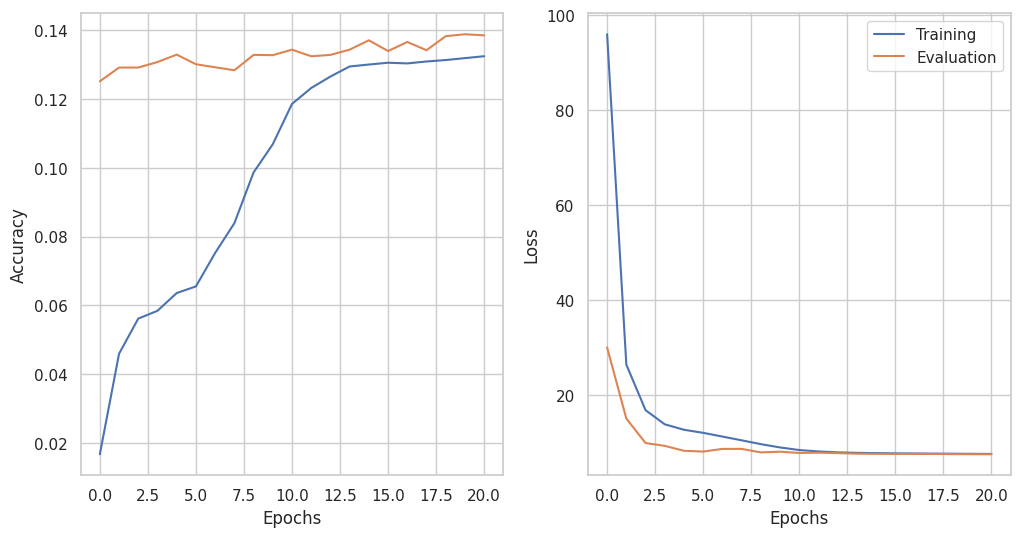

In [47]:

fig, axs = plt.subplots(nrows = 1, ncols =2 , figsize = (12,6))
epochs = list(range(len(train_accs)))
axs[0].plot(epochs,train_accs, label = "Training")
axs[0].plot(epochs, val_accs, label = "Evaluation")
axs[1].plot(epochs, train_losses, label = "Training")
axs[1].plot(epochs, val_losses, label = "Evaluation")
axs[0].set_xlabel("Epochs")
axs[1].set_xlabel("Epochs")
axs[0].set_ylabel("Accuracy")
axs[1].set_ylabel("Loss")
plt.legend()
plt.savefig('./training_curves.png')
plt.show()

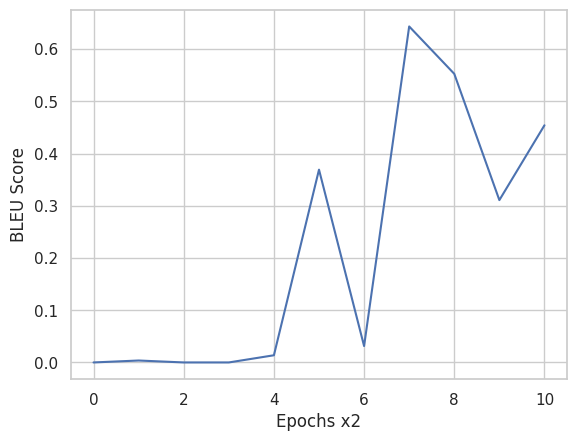

In [48]:
epochs = list(range(len(bleu_scores)))
plt.plot(epochs, bleu_scores)
plt.xlabel("Epochs x2")
plt.ylabel("BLEU Score")
plt.savefig('./bleu_scores.png')
plt.show()

In [49]:
@torch.no_grad()
def inference(zhs):
    preds = []
    model.eval()
    for zh in zhs:
        src = zh_tokenizer.encode(zh).ids
        src = torch.tensor(src, device=DEVICE).unsqueeze(0)
        src = src[:, :MAX_LEN]
        src_key_padding_mask = src == ZH_PAD_TOKEN_ID
        preds.append(beam_search_decode(src, src_key_padding_mask, beam_size=4, max_len=MAX_LEN + 5))
    return preds

In [50]:
zh_private = []
with open(private_path / "private_test.zh", "r", encoding="utf-8") as f:
     zh_private = f.read().splitlines()
vi_private = inference(zh_private)

KeyboardInterrupt: 

In [ ]:
len(zh_private), len(vi_private)

In [ ]:
public_submit = pd.DataFrame({
    "tieng_trung": zh_private,
    "tieng_viet": vi_private
})

In [ ]:
public_submit.sample(5)

In [ ]:
public_submit.to_csv("nlp_submission.csv", index=False)

In [ ]:
!zip -r "nlp.zip" nlp_submission.csv